In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

In [31]:
path = "/content/drive/MyDrive/Churn_Modelling.csv"

df = pd.read_csv(path)

In [32]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [33]:
import tensorflow as tf
print(tf.__version__)

2.20.0


## Import Basic Libraries

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [35]:
## Divide the dataset into independent and dependent features

X = df.iloc[:,3:13]
y = df.iloc[:,13]

In [12]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [13]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [36]:
# Feature Engineering
geography=pd.get_dummies(X["Geography"],drop_first=True)
geography
gender=pd.get_dummies(X['Gender'], drop_first=True)
gender

,Male
0,False
1,False
2,False
3,False
4,False
...,...
9995,True
9996,True
9997,False
9998,True


In [37]:
X = X.drop(['Geography','Gender'], axis=1, errors='ignore')
X = pd.concat([X, geography, gender], axis=1)

In [26]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True,True,False,True


In [38]:
# splitting the dataset into Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0 )



In [ ]:
# For which all algorithms feature scaling is required
#1. ANN 2.LR 3. Log R 4. Rf 5.Decision Tree
#6. XGB  7. KNN 8. Kmeans



In [39]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)



In [40]:
X_train.shape

(8000, 11)

In [41]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

## Part 2

In [53]:
# Now lets Create the ANN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU
from tensorflow.keras.layers import Dropout

In [54]:
### Lets  initialize the ANN
classifiers = Sequential()



In [55]:
# Adding the input Layer
classifiers.add(Dense(units=11, activation='relu'))


In [ ]:
# Adding the first hidden layer
classifiers.add(Dense(units=7, activation='relu'))
classifiers.add(Dropout(0.2))

In [82]:

# Adding  the second hidden layer
classifiers.add(Dense(units=6, activation='relu'))
classifiers.add(Dropout(0.3))

In [83]:
# Adding the output layer
classifiers.add(Dense(units=1 ,activation='sigmoid'))


In [84]:
classifiers.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])

In [85]:
import tensorflow
learning_rate = 0.01 # Define the learning rate
adam_optimizer = tensorflow.keras.optimizers.Adam(learning_rate=learning_rate)

In [86]:
model_history = classifiers.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)


Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7962 - loss: 0.5634 - val_accuracy: 0.7955 - val_loss: 0.5106
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7962 - loss: 0.5260 - val_accuracy: 0.7955 - val_loss: 0.4951
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.5059 - val_accuracy: 0.7955 - val_loss: 0.4716
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.4703 - val_accuracy: 0.7955 - val_loss: 0.4476
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.4608 - val_accuracy: 0.7955 - val_loss: 0.4354
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.4543 - val_accuracy: 0.7955 - val_loss: 0.4300
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.4552 - val_accuracy: 0.7955 - val_loss: 0.4363
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.4448 - val_accu

In [62]:
# ## Early stopping
# import tensorflow as tf
# from tensorflow.keras.callbacks import EarlyStopping
# early_stoppimg = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     min_delta=0,
#     patience=0,
#     verbose=0,
#     mode='auto',
#     baseline=None,
#     restore_best_weights=False,
#     start_from_epoch=0
# )


In [87]:
#  Early stopping

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
early_stoppimg = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0
)

In [88]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

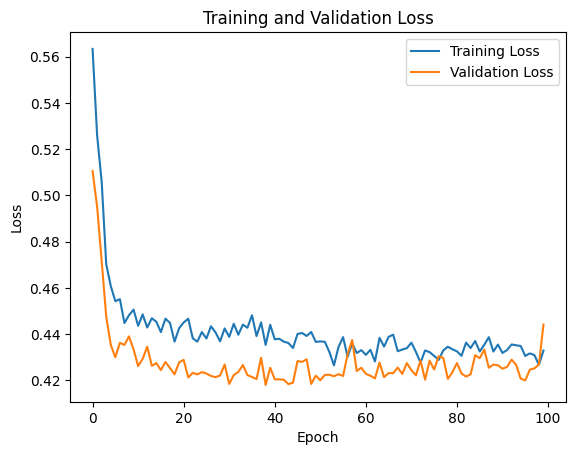

In [90]:
plt.plot(model_history.history['loss'], label='Training Loss')
plt.plot(model_history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Part 3 - Making the Predictions and Evaluating the Model

In [91]:
y_pred = classifiers.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [92]:
## Make the Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm


array([[1595,    0],
       [ 405,    0]])

In [93]:
### Calculate the Accuracy
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
score

0.7975

In [94]:
##  Get the Weights
classifiers.get_weights()

[array([[ 3.75652492e-01,  6.35964215e-01, -3.65410358e-01,
         -2.05227479e-01, -5.37177697e-02, -1.90926030e-01,
         -1.80509359e-01,  9.60624740e-02, -6.87344149e-02,
          1.21392839e-01,  1.72640622e-01],
        [-7.99326181e-01, -4.06809241e-01, -1.01544738e+00,
          1.06860161e+00, -3.96260142e-01, -6.79339528e-01,
          1.15633285e+00,  5.61342478e-01,  1.19328056e-03,
          6.21673465e-01,  6.81413040e-02],
        [-5.08540511e-01, -3.62508237e-01,  4.99390811e-01,
          2.16136187e-01,  2.00920597e-01,  2.26123080e-01,
         -1.99620426e-01,  1.93294451e-01, -3.23657900e-01,
          7.73514628e-01,  2.96904538e-02],
        [-7.17057109e-01,  1.67869821e-01, -1.50160983e-01,
         -1.03842437e+00, -4.92231667e-01,  8.36144388e-01,
          4.53528076e-01, -1.42655447e-01, -7.08288193e-01,
         -9.22446012e-01,  1.02856672e+00],
        [-3.82116646e-01, -2.56285101e-01, -4.28255677e-01,
         -1.60741377e+00, -3.21066022e-01,  